# IEOR E4004 — Project I: Eliminating Child Care Deserts in NYC
## Problem of Budgeting (P1) & Realistic Expansion (P2)

| Part | Content |
|------|---------|
| 1 | Data Loading & Cleaning |
| 2 | Feature Engineering & Desert Classification |
| 3 | EDA & Visualizations |
| 4 | Problem 1 — Idealistic Budgeting (Gurobi MIP) |
| 5 | Problem 2 — Realistic Expansion with Distance Constraints (Gurobi MIP) |

## Imports

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import warnings, math
import gurobipy as gp
from gurobipy import GRB

warnings.filterwarnings('ignore')
np.random.seed(42)

PALETTE = {'desert':'#d62728','ok':'#2ca02c','high':'#ff7f0e','normal':'#1f77b4'}
BOR_COLORS = {
    'Manhattan':'#3498db','Bronx':'#e74c3c','Brooklyn':'#2ecc71',
    'Queens':'#e67e22','Staten Island':'#9b59b6','Unknown':'#95a5a6',
}

def get_borough(z):
    z = int(z)
    if   10001 <= z <= 10282: return 'Manhattan'
    elif 10451 <= z <= 10475: return 'Bronx'
    elif 11200 <= z <= 11257: return 'Brooklyn'
    elif z in {11004,11005,11101,11102,11103,11104,11105,11106,11109}          or 11354 <= z <= 11697: return 'Queens'
    elif 10301 <= z <= 10314: return 'Staten Island'
    return 'Unknown'

def haversine_miles(lat1, lon1, lat2, lon2):
    """Great-circle distance in miles."""
    R = 3958.8
    lat1,lon1,lat2,lon2 = map(math.radians,[lat1,lon1,lat2,lon2])
    a = (math.sin((lat2-lat1)/2)**2
         + math.cos(lat1)*math.cos(lat2)*math.sin((lon2-lon1)/2)**2)
    return 2*R*math.asin(math.sqrt(a))

# c_slots: piece-1 cost per slot — step function decreasing in n_f
def c_slots(n):
    if   n <= 20:  return 1200.0
    elif n <= 50:  return 600.0
    elif n <= 100: return 400.0
    elif n <= 200: return 300.0
    else:          return 20000.0/n + 200.0

# piece-2 cost per slot: (20000 + 200*nf)/nf
def c_slots_p2(n):
    return (20000.0 + 200.0*n) / n

print("Setup complete.")

Setup complete.


---
## Part 1 — Data Loading & Cleaning

### 1.1  Load raw files

In [2]:
fac_raw = pd.read_csv('child_care_regulated_nyc.csv')
pop_raw = pd.read_csv('population_nyc.csv')
inc_raw = pd.read_csv('avg_individual_income_nyc.csv')
emp_raw = pd.read_csv('employment_rate_nyc.csv')
loc_raw = pd.read_csv('potential_locations_nyc.csv')

for df in [fac_raw,pop_raw,inc_raw,emp_raw,loc_raw]:
    df.drop(columns=[c for c in df.columns if 'Unnamed' in c], inplace=True)

summary = pd.DataFrame({
    'Dataset':  ['Facilities','Population','Income','Employment','Locations'],
    'Rows':     [len(fac_raw),len(pop_raw),len(inc_raw),len(emp_raw),len(loc_raw)],
    'Columns':  [fac_raw.shape[1],pop_raw.shape[1],inc_raw.shape[1],
                 emp_raw.shape[1],loc_raw.shape[1]],
    'Nulls':    [df.isnull().sum().sum()
                 for df in [fac_raw,pop_raw,inc_raw,emp_raw,loc_raw]],
})
display(summary)

,Dataset,Rows,Columns,Nulls
0,Facilities,7740,15,353
1,Population,211,20,0
2,Income,179,2,0
3,Employment,179,2,0
4,Locations,31100,3,0


### 1.2  Data quality audit

In [3]:
z_inc = set(inc_raw['zipcode'])
z_pop = set(pop_raw['zipcode'])

pop_raw['children_0_12'] = pop_raw['-5'] + pop_raw['6-12']
pop_with_children = set(pop_raw[pop_raw['children_0_12'] > 0]['zipcode'])

# ZIPs with children but missing from income/employment
impute_needed = sorted(pop_with_children - z_inc)
print(f"ZIPs with children but no income/employment data: {impute_needed}")
for z in impute_needed:
    row = pop_raw[pop_raw['zipcode']==z].iloc[0]
    print(f"  ZIP {z} ({get_borough(z)}): "
          f"pop_0_5={row['-5']}, pop_6_12={row['6-12']}")

n_inactive  = (~fac_raw['facility_status'].isin(['License','Registration'])).sum()
n_zero_cap  = (fac_raw['total_capacity']==0).sum()
n_null_ll   = fac_raw['latitude'].isna().sum()
print(f"\nFacility issues:")
print(f"  Inactive / revoked status : {n_inactive}  -> DROP")
print(f"  Zero total_capacity       : {n_zero_cap}  -> DROP")
print(f"  Missing lat/lon           : {n_null_ll}  -> impute from ZIP mean")

ZIPs with children but no income/employment data: [11249, 11430]
  ZIP 11249 (Brooklyn): pop_0_5=4774, pop_6_12=4836
  ZIP 11430 (Queens): pop_0_5=0, pop_6_12=37

Facility issues:
  Inactive / revoked status : 27  -> DROP
  Zero total_capacity       : 1  -> DROP
  Missing lat/lon           : 169  -> impute from ZIP mean


### 1.3  Clean facilities

In [4]:
fac = fac_raw.copy()

# (a) Active only
fac = fac[fac['facility_status'].isin(['License','Registration'])].copy()

# (b) Non-zero capacity
fac = fac[fac['total_capacity'] > 0].copy()

# (c) Age-0-5 capacity:
#     GFDC and FDC facilities store 0-5 slots in children_capacity.
#     Centre-based facilities (SACC) use infant/toddler/preschool columns.
#     Using the union gives the correct 0-5 total (~69,690 slots).
fac['cap_0_5'] = (fac['children_capacity']
                  + fac['infant_capacity']
                  + fac['toddler_capacity']
                  + fac['preschool_capacity'])

# (d) Borough label
fac['borough'] = fac['zipcode'].apply(get_borough)

# (e) Impute missing lat/lon from mean of other facilities in same ZIP
zip_ll = (fac.dropna(subset=['latitude','longitude'])
          .groupby('zipcode')[['latitude','longitude']].mean())
mask = fac['latitude'].isna()
fac.loc[mask,'latitude']  = fac.loc[mask,'zipcode'].map(zip_ll['latitude'])
fac.loc[mask,'longitude'] = fac.loc[mask,'zipcode'].map(zip_ll['longitude'])

fac = fac.reset_index(drop=True)
print(f"Facilities: {len(fac_raw):,}  ->  {len(fac):,} active, non-zero-cap rows")
print(f"  Remaining lat/lon nulls: {fac['latitude'].isna().sum()}")
display(fac[['facility_id','zipcode','borough','total_capacity',
             'cap_0_5','latitude','longitude']].head())

Facilities: 7,740  ->  7,712 active, non-zero-cap rows
  Remaining lat/lon nulls: 0


,facility_id,zipcode,borough,total_capacity,cap_0_5,latitude,longitude
0,51349,10474,Bronx,6,6,40.818399,-73.888816
1,73544,10017,Manhattan,60,0,40.753216,-73.970794
2,108407,11225,Brooklyn,16,12,40.663235,-73.954284
3,111953,11226,Brooklyn,16,12,40.646785,-73.956955
4,126425,10465,Bronx,12,12,40.841228,-73.823572


### 1.4  Clean population

In [5]:
pop = pop_raw.copy()
pop = pop.rename(columns={'-5':'pop_0_5','6-12':'pop_6_12'})
pop['pop_0_12'] = pop['pop_0_5'] + pop['pop_6_12']
pop['borough']  = pop['zipcode'].apply(get_borough)
pop = pop[['zipcode','borough','pop_0_5','pop_6_12','pop_0_12']].copy()
print(f"Population: {len(pop)} ZIP codes")
display(pop.head())

Population: 211 ZIP codes


,zipcode,borough,pop_0_5,pop_6_12,pop_0_12
0,10001,Manhattan,744,1255,1999
1,10002,Manhattan,2142,4645,6787
2,10003,Manhattan,1440,1510,2950
3,10004,Manhattan,433,262,695
4,10005,Manhattan,484,318,802


### 1.5  Clean income & employment — impute 2 missing ZIPs

In [6]:
inc = inc_raw[['zipcode','average income']].copy()
emp = emp_raw[['zipcode','employment rate']].copy()

# Borough medians for imputation
base = inc.merge(emp, on='zipcode').copy()
base['borough'] = base['zipcode'].apply(get_borough)
bor_inc = base.groupby('borough')['average income'].median()
bor_emp = base.groupby('borough')['employment rate'].median()

impute_needed = sorted(set(pop[pop['pop_0_12']>0]['zipcode']) - set(inc['zipcode']))
rows_inc, rows_emp = [], []
for z in impute_needed:
    b = get_borough(z)
    rows_inc.append({'zipcode':z, 'average income':  round(bor_inc[b],2)})
    rows_emp.append({'zipcode':z, 'employment rate': round(bor_emp[b],6)})
    print(f"  ZIP {z} ({b}): income=${bor_inc[b]:,.0f}, "
          f"emp_rate={bor_emp[b]:.4f}  [imputed]")

inc = pd.concat([inc, pd.DataFrame(rows_inc)], ignore_index=True)
emp = pd.concat([emp, pd.DataFrame(rows_emp)], ignore_index=True)
print(f"Income: {len(inc_raw)} -> {len(inc)} rows")
print(f"Employment: {len(emp_raw)} -> {len(emp)} rows")

  ZIP 11249 (Brooklyn): income=$55,444, emp_rate=0.4559  [imputed]
  ZIP 11430 (Queens): income=$59,109, emp_rate=0.4869  [imputed]
Income: 179 -> 181 rows
Employment: 179 -> 181 rows


### 1.6  Clean potential locations

In [7]:
# Filter to ZIPs that appear in income/employment (our working set)
WORKING_ZIPS = set(inc['zipcode']) & set(pop[pop['pop_0_12']>0]['zipcode'])
print(f"Working ZIP count: {len(WORKING_ZIPS)}")

loc = loc_raw.copy()
loc = loc[loc['zipcode'].isin(WORKING_ZIPS)].reset_index(drop=True)
loc['borough'] = loc['zipcode'].apply(get_borough)
print(f"Potential locations: {len(loc_raw):,} -> {len(loc):,} "
      f"(filtered to {loc['zipcode'].nunique()} working ZIPs)")
print(f"Locations per ZIP: {loc.groupby('zipcode').size().describe()[['min','max','mean']].to_dict()}")

Working ZIP count: 180
Potential locations: 31,100 -> 18,000 (filtered to 180 working ZIPs)
Locations per ZIP: {'min': 100.0, 'max': 100.0, 'mean': 100.0}


---
## Part 2 — Feature Engineering & Desert Classification

### 2.1  Build master ZIP-level DataFrame

In [8]:
master = (pop[pop['zipcode'].isin(WORKING_ZIPS)]
          .merge(inc, on='zipcode')
          .merge(emp, on='zipcode'))

# Aggregate facility capacity per ZIP
cc_zip = (fac[fac['zipcode'].isin(WORKING_ZIPS)]
          .groupby('zipcode')
          .agg(n_facilities =('facility_id','count'),
               total_slots  =('total_capacity','sum'),
               slots_0_5    =('cap_0_5','sum'))
          .reset_index())

master = master.merge(cc_zip, on='zipcode', how='left')
master['n_facilities'] = master['n_facilities'].fillna(0).astype(int)
master['total_slots']  = master['total_slots'].fillna(0).astype(int)
master['slots_0_5']    = master['slots_0_5'].fillna(0).astype(int)

print(f"Master DataFrame: {master.shape}")
display(master.head())

Master DataFrame: (180, 10)


,zipcode,borough,pop_0_5,pop_6_12,pop_0_12,average income,employment rate,n_facilities,total_slots,slots_0_5
0,10001,Manhattan,744,1255,1999,102878.033603,0.595097,9,609,24
1,10002,Manhattan,2142,4645,6787,59604.041165,0.520662,56,4724,216
2,10003,Manhattan,1440,1510,2950,114273.049645,0.497244,7,1995,0
3,10004,Manhattan,433,262,695,132004.310345,0.506661,2,263,0
4,10005,Manhattan,484,318,802,121437.713311,0.665833,1,39,0


### 2.2  Desert classification & deficit calculation

In [9]:
# High-demand: emp_rate >= 60% OR avg_income <= $60,000
master['high_demand'] = ((master['employment rate'] >= 0.60) |
                          (master['average income']  <= 60_000))

# Desert threshold per ZIP
master['desert_threshold'] = np.where(
    master['high_demand'],
    0.5  * master['pop_0_12'],
    (1/3)* master['pop_0_12']
)

# Desert flag: slots <= threshold (strictly need slots > threshold to exit)
master['is_desert'] = master['total_slots'] <= master['desert_threshold']

# Required slots: must be STRICTLY greater than threshold
master['req_total'] = (np.floor(master['desert_threshold']) + 1).astype(int)

# Deficit to exit desert
master['total_deficit'] = np.where(
    master['is_desert'],
    (master['req_total'] - master['total_slots']).clip(lower=0),
    0
).astype(int)

# Age 0-5 NYC policy: available 0-5 slots >= (2/3) * pop_0_5
master['req_0_5']    = np.ceil((2/3) * master['pop_0_5']).astype(int)
master['deficit_0_5']= (master['req_0_5'] - master['slots_0_5']).clip(lower=0).astype(int)
master['fails_u5']   = master['slots_0_5'] < master['req_0_5']

# Coverage ratio
master['coverage_ratio'] = (master['total_slots'] /
                             master['pop_0_12'].replace(0, np.nan))

print(f"Working ZIPs         : {len(master)}")
print(f"High-demand ZIPs     : {master['high_demand'].sum()}  "
      f"({master['high_demand'].mean():.1%})")
print(f"Child care deserts   : {master['is_desert'].sum()}  "
      f"({master['is_desert'].mean():.1%})")
print(f"  High-demand deserts: {(master['high_demand']&master['is_desert']).sum()}")
print(f"  Normal deserts     : {(~master['high_demand']&master['is_desert']).sum()}")
print(f"Total slot deficit   : {master['total_deficit'].sum():,}")
print(f"Total 0-5 deficit    : {master['deficit_0_5'].sum():,}")
print(f"ZIPs failing 0-5 rule: {master['fails_u5'].sum()}")

Working ZIPs         : 180
High-demand ZIPs     : 97  (53.9%)
Child care deserts   : 162  (90.0%)
  High-demand deserts: 91
  Normal deserts     : 71
Total slot deficit   : 238,068
Total 0-5 deficit    : 277,184
ZIPs failing 0-5 rule: 179


Monte Carlo Results (N=1,000 simulations)
Noise: emp_rate ±0.03, income ±5%, population ±3%



,Metric,Observed,MC Mean,MC P5,MC P95
0,Total slot deficit,238068,"239,698","234,351","244,820"
1,Under-5 deficit,277184,"277,215","275,739","278,672"
2,# Desert ZIPs,162,161.4,159,163
3,# High-demand ZIPs,97,97.0,93,101


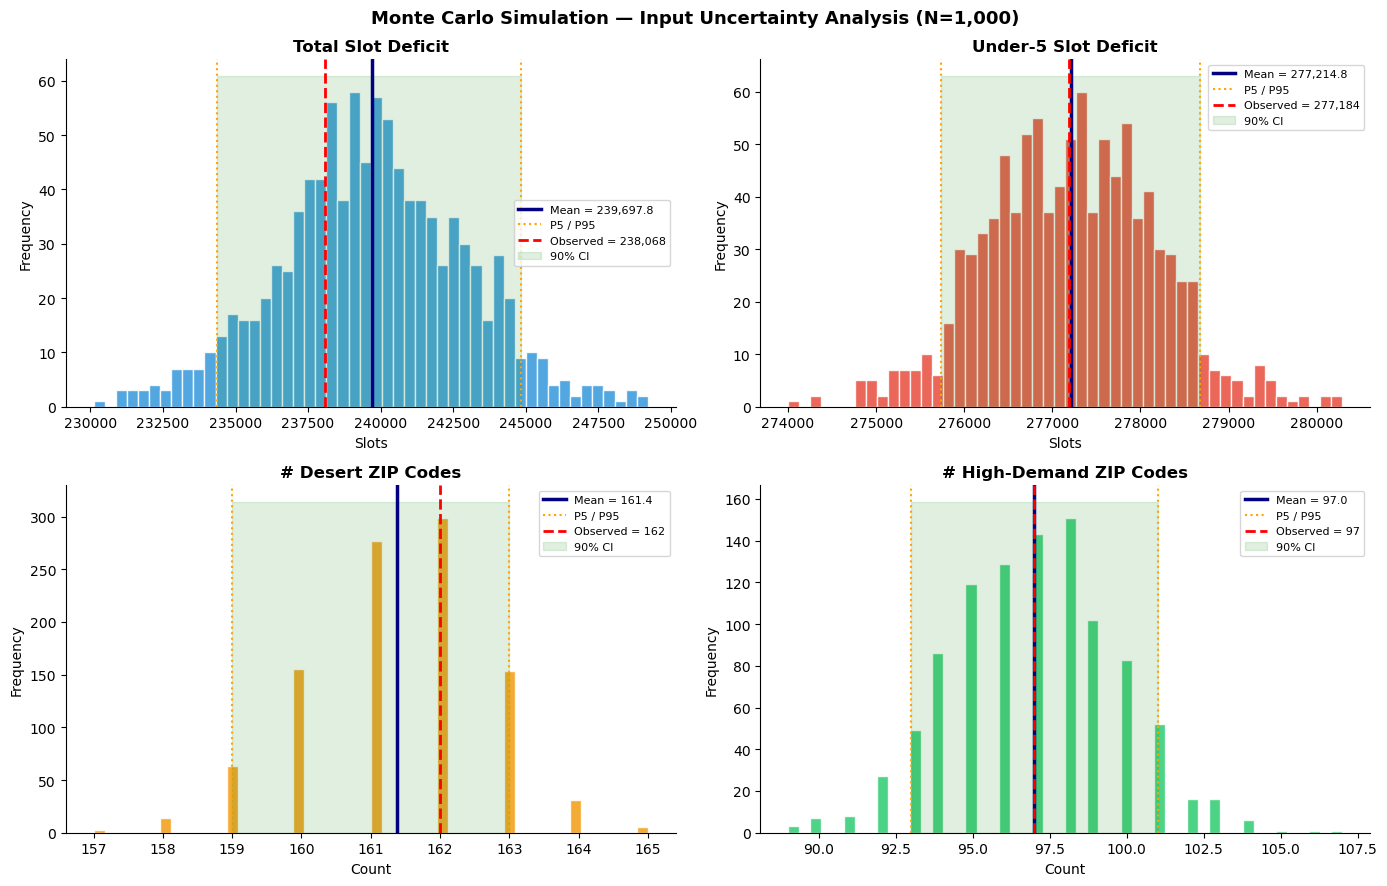


90% CI — Total slot deficit  : [234,351  –  244,820]
90% CI — Under-5 deficit     : [275,739  –  278,672]
90% CI — # Desert ZIPs       : [159  –  163]


In [26]:
# ─────────────────────────────────────────────────────────────
# MONTE CARLO SIMULATION
# Purpose: quantify how sensitive the desert classification and
# slot deficit are to uncertainty in the three key inputs:
#   - employment rate  (σ = 0.03, i.e. ±3 percentage points)
#   - average income   (σ = 5%  of observed value)
#   - child population (σ = 3%  of observed value)
# We run N=1,000 simulations. In each run we:
#   1. Perturb inputs with Gaussian noise
#   2. Recompute high_demand flag and desert threshold
#   3. Recompute total slot deficit across all ZIPs
# This gives a distribution over possible deficit outcomes.
# ─────────────────────────────────────────────────────────────

N_SIM = 1_000

emp_obs  = master['employment rate'].values.copy()
inc_obs  = master['average income'].values.copy()
pop_obs  = master['pop_0_12'].values.copy()
p05_obs  = master['pop_0_5'].values.copy()
exist_obs= master['total_slots'].values.copy()

mc_total_deficit = np.zeros(N_SIM)
mc_u5_deficit    = np.zeros(N_SIM)
mc_n_deserts     = np.zeros(N_SIM, dtype=int)
mc_n_hd          = np.zeros(N_SIM, dtype=int)

for i in range(N_SIM):
    # Perturb inputs (clip to realistic bounds)
    emp_s = np.clip(emp_obs + np.random.normal(0, 0.03, len(master)), 0.20, 0.98)
    inc_s = np.clip(inc_obs * (1 + np.random.normal(0, 0.05, len(master))), 10_000, None)
    pop_s = np.clip(pop_obs * (1 + np.random.normal(0, 0.03, len(master))), 0, None)
    p05_s = pop_s * (p05_obs / np.where(pop_obs > 0, pop_obs, 1))  # scale proportionally

    # Recompute classification
    hd_s   = (emp_s >= 0.60) | (inc_s <= 60_000)
    thr_s  = np.where(hd_s, 0.5 * pop_s, (1/3) * pop_s)
    req_s  = np.floor(thr_s) + 1
    req05_s= np.ceil((2/3) * p05_s)

    deficit_s    = (req_s   - exist_obs).clip(min=0)
    u5_deficit_s = (req05_s - master['slots_0_5'].values).clip(min=0)

    mc_total_deficit[i] = deficit_s.sum()
    mc_u5_deficit[i]    = u5_deficit_s.sum()
    mc_n_deserts[i]     = (deficit_s > 0).sum()
    mc_n_hd[i]          = hd_s.sum()

# ── Summary statistics ────────────────────────────────────────
mc_results = pd.DataFrame({
    'Metric':   ['Total slot deficit','Under-5 deficit',
                 '# Desert ZIPs','# High-demand ZIPs'],
    'Observed': [int(master['total_deficit'].sum()),
                 int(master['deficit_0_5'].sum()),
                 int(master['is_desert'].sum()),
                 int(master['high_demand'].sum())],
    'MC Mean':  [f"{mc_total_deficit.mean():,.0f}",
                 f"{mc_u5_deficit.mean():,.0f}",
                 f"{mc_n_deserts.mean():.1f}",
                 f"{mc_n_hd.mean():.1f}"],
    'MC P5':    [f"{np.percentile(mc_total_deficit,5):,.0f}",
                 f"{np.percentile(mc_u5_deficit,5):,.0f}",
                 f"{np.percentile(mc_n_deserts,5):.0f}",
                 f"{np.percentile(mc_n_hd,5):.0f}"],
    'MC P95':   [f"{np.percentile(mc_total_deficit,95):,.0f}",
                 f"{np.percentile(mc_u5_deficit,95):,.0f}",
                 f"{np.percentile(mc_n_deserts,95):.0f}",
                 f"{np.percentile(mc_n_hd,95):.0f}"],
})
print("Monte Carlo Results (N=1,000 simulations)")
print("Noise: emp_rate ±0.03, income ±5%, population ±3%\n")
display(mc_results)

# ── Visualizations ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Monte Carlo Simulation — Input Uncertainty Analysis (N=1,000)',
             fontsize=13, fontweight='bold')

for ax, vals, base, lbl, unit, c in [
    (axes[0,0], mc_total_deficit, master['total_deficit'].sum(),
     'Total Slot Deficit', 'Slots', '#3498db'),
    (axes[0,1], mc_u5_deficit, master['deficit_0_5'].sum(),
     'Under-5 Slot Deficit', 'Slots', '#e74c3c'),
    (axes[1,0], mc_n_deserts, master['is_desert'].sum(),
     '# Desert ZIP Codes', 'Count', '#f39c12'),
    (axes[1,1], mc_n_hd, master['high_demand'].sum(),
     '# High-Demand ZIP Codes', 'Count', '#2ecc71'),
]:
    ax.hist(vals, bins=50, color=c, edgecolor='white', alpha=0.85)
    mn   = vals.mean()
    p5   = np.percentile(vals, 5)
    p95  = np.percentile(vals, 95)
    ax.axvline(mn,   color='navy',   lw=2.5, label=f'Mean = {mn:,.1f}')
    ax.axvline(p5,   color='orange', lw=1.5, ls=':', label='P5 / P95')
    ax.axvline(p95,  color='orange', lw=1.5, ls=':')
    ax.axvline(base, color='red',    lw=2,   ls='--', label=f'Observed = {base:,.0f}')
    ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1]>0 else 1],
                     p5, p95, alpha=0.12, color='green', label='90% CI')
    ax.set_ylim(bottom=0)
    ax.set_xlabel(unit)
    ax.set_ylabel('Frequency')
    ax.set_title(lbl, fontweight='bold')
    ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('mc_simulation.png', bbox_inches='tight', dpi=120)
plt.show()

print(f"\n90% CI — Total slot deficit  : "
      f"[{np.percentile(mc_total_deficit,5):,.0f}  –  {np.percentile(mc_total_deficit,95):,.0f}]")
print(f"90% CI — Under-5 deficit     : "
      f"[{np.percentile(mc_u5_deficit,5):,.0f}  –  {np.percentile(mc_u5_deficit,95):,.0f}]")
print(f"90% CI — # Desert ZIPs       : "
      f"[{np.percentile(mc_n_deserts,5):.0f}  –  {np.percentile(mc_n_deserts,95):.0f}]")

---
## Part 3 — EDA & Visualizations

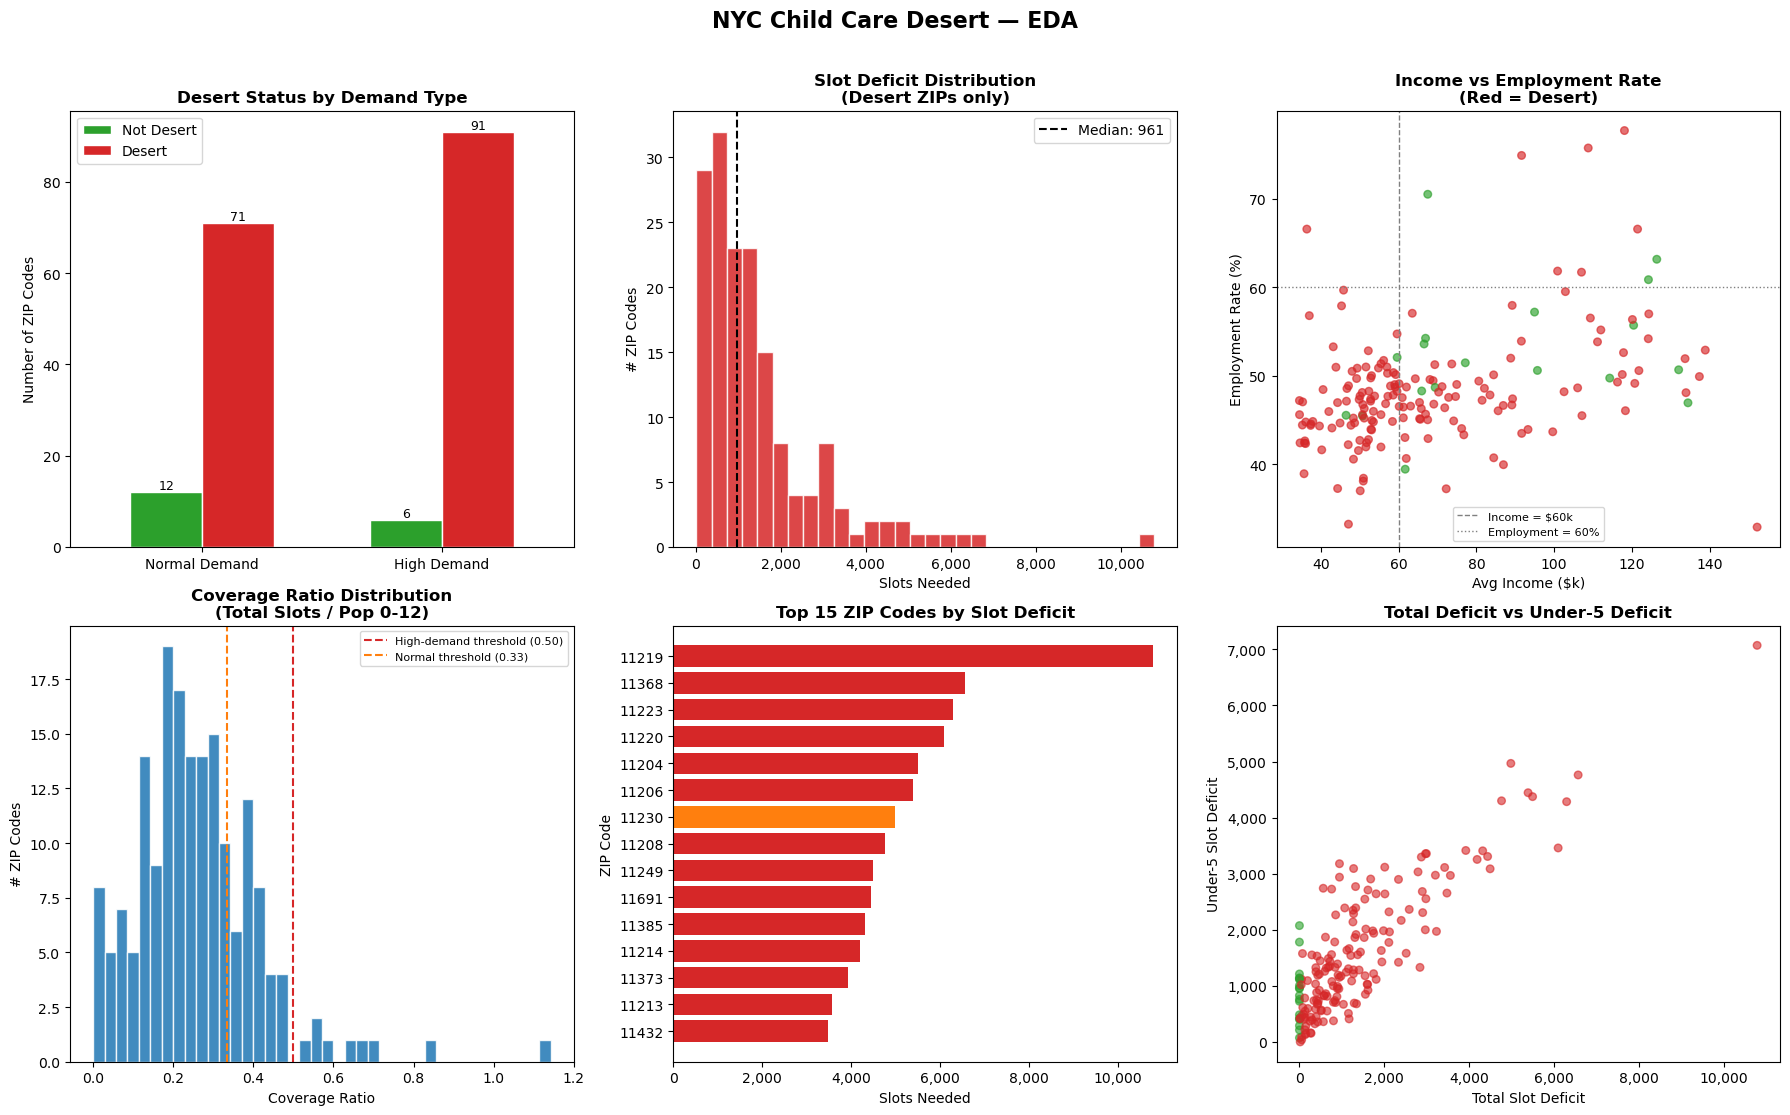

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('NYC Child Care Desert — EDA', fontsize=16, fontweight='bold', y=1.01)

# Plot 1: Desert status by demand type
ax = axes[0,0]
counts = (master.groupby(['high_demand','is_desert'])
          .size().unstack(fill_value=0))
counts.index = ['Normal Demand','High Demand']
counts.columns = ['Not Desert','Desert']
counts.plot(kind='bar', ax=ax,
            color=[PALETTE['ok'],PALETTE['desert']],
            edgecolor='white', width=0.6)
ax.set_title('Desert Status by Demand Type', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Number of ZIP Codes')
ax.set_xticklabels(counts.index, rotation=0)
for c in ax.containers:
    ax.bar_label(c, fontsize=9)
ax.legend()

# Plot 2: Slot deficit distribution (desert ZIPs only)
ax = axes[0,1]
d = master[master['total_deficit']>0]['total_deficit']
ax.hist(d, bins=30, color=PALETTE['desert'], edgecolor='white', alpha=0.85)
ax.axvline(d.median(), color='black', ls='--', lw=1.5,
           label=f'Median: {d.median():,.0f}')
ax.set_title('Slot Deficit Distribution\n(Desert ZIPs only)', fontweight='bold')
ax.set_xlabel('Slots Needed'); ax.set_ylabel('# ZIP Codes')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.legend()

# Plot 3: Income vs Employment Rate scatter
ax = axes[0,2]
colors = master['is_desert'].map({True:PALETTE['desert'],False:PALETTE['ok']})
ax.scatter(master['average income']/1000, master['employment rate']*100,
           c=colors, alpha=0.65, s=30)
ax.axvline(60, color='gray', ls='--', lw=1, label='Income = $60k')
ax.axhline(60, color='gray', ls=':',  lw=1, label='Employment = 60%')
ax.set_title('Income vs Employment Rate\n(Red = Desert)', fontweight='bold')
ax.set_xlabel('Avg Income ($k)'); ax.set_ylabel('Employment Rate (%)')
ax.legend(fontsize=8)

# Plot 4: Coverage ratio distribution
ax = axes[1,0]
ax.hist(master['coverage_ratio'].dropna(), bins=40,
        color=PALETTE['normal'], edgecolor='white', alpha=0.85)
ax.axvline(0.5, color=PALETTE['desert'], ls='--', lw=1.5,
           label='High-demand threshold (0.50)')
ax.axvline(1/3, color=PALETTE['high'], ls='--', lw=1.5,
           label='Normal threshold (0.33)')
ax.set_title('Coverage Ratio Distribution\n(Total Slots / Pop 0-12)', fontweight='bold')
ax.set_xlabel('Coverage Ratio'); ax.set_ylabel('# ZIP Codes')
ax.legend(fontsize=8)

# Plot 5: Top 15 worst deserts
ax = axes[1,1]
top15 = master.nlargest(15,'total_deficit')[
    ['zipcode','total_deficit','high_demand']].copy()
top15['zipcode'] = top15['zipcode'].astype(str)
bar_c = top15['high_demand'].map({True:PALETTE['desert'],
                                   False:PALETTE['high']}).values
ax.barh(top15['zipcode'][::-1], top15['total_deficit'][::-1],
        color=bar_c[::-1])
ax.set_title('Top 15 ZIP Codes by Slot Deficit', fontweight='bold')
ax.set_xlabel('Slots Needed'); ax.set_ylabel('ZIP Code')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# Plot 6: Total deficit vs under-5 deficit
ax = axes[1,2]
ax.scatter(master['total_deficit'], master['deficit_0_5'],
           c=master['is_desert'].map({True:PALETTE['desert'],
                                       False:PALETTE['ok']}),
           alpha=0.6, s=30)
ax.set_title('Total Deficit vs Under-5 Deficit', fontweight='bold')
ax.set_xlabel('Total Slot Deficit'); ax.set_ylabel('Under-5 Slot Deficit')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('eda_plots.png', bbox_inches='tight', dpi=120)
plt.show()

---
## Part 4 — Problem 1: Idealistic Budgeting

### Mathematical Formulation

**Sets:**
- Z = working ZIP codes; F(z) = active facilities in ZIP z; S = {small, medium, large}

**Per-ZIP parameters:**
- `N_z = Σ_{f∈F(z)} n_f` — sum of current slots
- `UB1_z = N_z` — piece-1 headroom (can expand up to n_f per facility, summed)
- `UB_z = Σ_f min(1.2·n_f, 500)` — total expansion cap
- `avg_cs1_z` = capacity-weighted average of `c_slots(n_f)` (piece-1 rate)
- `avg_cs2_z` = capacity-weighted average of `(20000+200·n_f)/n_f` (piece-2 rate)

**Decision variables:**
- `X1[z] ≥ 0` — piece-1 expansion slots in ZIP z (x_f < n_f regime, per facility)
- `X2[z] ≥ 0` — piece-2 expansion slots in ZIP z (x_f ≥ n_f regime)
- `U[z] ≥ 0` — under-5 slots added via expansion in ZIP z
- `y[z,s] ∈ ℤ≥0` — number of size-s new facilities in ZIP z

**Objective — minimize total funding:**
```
min  Σ_z [ avg_cs1_z·X1[z] + avg_cs2_z·X2[z] + 100·U[z]
         + Σ_s (C_s + 100·cap05_s)·y[z,s] ]
```

**Constraints:**
1. `X1[z] ≤ UB1_z`  (piece-1 range)
2. `X1[z] + X2[z] ≤ UB_z`  (total expansion cap)
3. `U[z] ≤ X1[z] + X2[z]`  (can't add more 0-5 than total expanded)
4. `existing_z + X1[z] + X2[z] + Σ_s cap_s·y[z,s] ≥ req_total_z`
5. `existing_0_5_z + U[z] + Σ_s cap05_s·y[z,s] ≥ req_0_5_z`

### 4.1  Compute ZIP-level parameters

In [12]:
SIZES = {
    'small':  {'cap':100, 'cap05': 50, 'cost': 65_000},
    'medium': {'cap':200, 'cap05':100, 'cost': 95_000},
    'large':  {'cap':400, 'cap05':200, 'cost':115_000},
}
EQUIP = 100   # $ per new/expanded 0-5 slot
sizes = list(SIZES.keys())

# Facilities restricted to working ZIPs, non-zero capacity
fac_w = fac[fac['zipcode'].isin(WORKING_ZIPS)].copy()

# Per-ZIP expansion parameters
def zip_expansion_params(group):
    nf    = group['total_capacity'].values.astype(float)
    N_z   = nf.sum()
    if N_z == 0:
        return pd.Series({'N_z':0,'UB1':0,'UB_total':0,
                          'avg_cs1':0,'avg_cs2':0})
    cs1   = np.array([c_slots(n)   for n in nf])
    cs2   = np.array([c_slots_p2(n) for n in nf])
    ub_f  = np.minimum(1.2*nf, 500)
    return pd.Series({
        'N_z':      N_z,
        'UB1':      N_z,                          # piece-1 headroom = sum nf
        'UB_total': ub_f.sum(),                   # total expansion cap
        'avg_cs1':  np.dot(cs1, nf) / N_z,        # capacity-weighted piece-1 rate
        'avg_cs2':  np.dot(cs2, nf) / N_z,        # capacity-weighted piece-2 rate
    })

zip_params = (fac_w.groupby('zipcode')
              .apply(zip_expansion_params)
              .reset_index())

# Merge with master
df1 = master.merge(zip_params, on='zipcode', how='left')
for c in ['N_z','UB1','UB_total','avg_cs1','avg_cs2']:
    df1[c] = df1[c].fillna(0)

print("ZIP-level expansion parameters computed.")
print(df1[['zipcode','total_slots','slots_0_5','N_z','UB_total',
           'avg_cs1','avg_cs2']].head(8).to_string(index=False))

ZIP-level expansion parameters computed.
 zipcode  total_slots  slots_0_5    N_z  UB_total    avg_cs1    avg_cs2
   10001          609         24  609.0     730.8 423.645320 495.566502
   10002         4724        216 4724.0    5668.8 359.398815 437.087214
   10003         1995          0 1995.0    2191.2 260.952381 270.175439
   10004          263          0  263.0     315.6 325.475285 352.091255
   10005           39          0   39.0      46.8 600.000000 712.820513
   10006          156         14  156.0     187.2 300.000000 328.205128
   10007          284          0  284.0     340.8 384.507042 411.267606
   10009         1784        124 1784.0    2140.8 377.186099 457.847534


### 4.2  Build and solve Gurobi model (Problem 1)

In [13]:
zips  = df1['zipcode'].tolist()
df1_i = df1.set_index('zipcode')

m1 = gp.Model('P1_Budgeting')
m1.setParam('OutputFlag', 1)
m1.setParam('MIPGap', 1e-4)
m1.setParam('TimeLimit', 300)

# ── Decision variables ────────────────────────────────────────
X1 = m1.addVars(zips, lb=0.0, name='X1')   # piece-1 expansion slots
X2 = m1.addVars(zips, lb=0.0, name='X2')   # piece-2 expansion slots
U  = m1.addVars(zips, lb=0.0, name='U')    # under-5 expansion slots
y  = m1.addVars(zips, sizes, lb=0, vtype=GRB.INTEGER, name='y')

# ── Constraints ───────────────────────────────────────────────
for z in zips:
    r = df1_i.loc[z]

    # 1. Piece-1 range cap
    m1.addConstr(X1[z] <= r['UB1'], name=f'ub1_{z}')

    # 2. Total expansion cap
    m1.addConstr(X1[z] + X2[z] <= r['UB_total'], name=f'ubt_{z}')

    # 3. Under-5 expansion bound
    m1.addConstr(U[z] <= X1[z] + X2[z], name=f'u5b_{z}')

    new_slots = gp.quicksum(SIZES[s]['cap']   * y[z,s] for s in sizes)
    new_u5    = gp.quicksum(SIZES[s]['cap05'] * y[z,s] for s in sizes)

    # 4. Desert elimination
    m1.addConstr(
        r['total_slots'] + X1[z] + X2[z] + new_slots >= r['req_total'],
        name=f'desert_{z}'
    )
    # 5. Age 0-5 NYC policy
    m1.addConstr(
        r['slots_0_5'] + U[z] + new_u5 >= r['req_0_5'],
        name=f'u5_{z}'
    )

# ── Objective ─────────────────────────────────────────────────
exp_cost   = gp.quicksum(
    df1_i.loc[z,'avg_cs1'] * X1[z] +
    df1_i.loc[z,'avg_cs2'] * X2[z] +
    EQUIP * U[z]
    for z in zips
)
build_cost = gp.quicksum(
    (SIZES[s]['cost'] + EQUIP*SIZES[s]['cap05']) * y[z,s]
    for z in zips for s in sizes
)
m1.setObjective(exp_cost + build_cost, GRB.MINIMIZE)

print(f"Variables  : {m1.NumVars:,}")
print(f"Constraints: {m1.NumConstrs:,}")
print("\nSolving...")
m1.optimize()
print(f"\nStatus: {m1.Status}  ({'OPTIMAL' if m1.Status==2 else 'OTHER'})")
print(f"Total cost: ${m1.ObjVal:,.0f}")

Set parameter Username
Set parameter LicenseID to value 2774010
Academic license - for non-commercial use only - expires 2027-02-02
Set parameter OutputFlag to value 1
Set parameter MIPGap to value 0.0001
Set parameter TimeLimit to value 300
Variables  : 0
Constraints: 0

Solving...
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 25.2.0 25C56)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Non-default parameters:
TimeLimit  300

Optimize a model with 900 rows, 1080 columns and 2700 nonzeros (Min)
Model fingerprint: 0xc5307a91
Model has 1072 linear objective coefficients
Variable types: 540 continuous, 540 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 4e+02]
  Objective range  [1e+02, 1e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e+01, 1e+04]

Found heuristic solution: objective 1.991250e+08
Presolve removed 896 rows and 1074 columns
Presolve time: 0.06s
Presolved: 4 rows,

### 4.3  Extract and display Problem 1 results

In [14]:
# ── Cost decomposition ────────────────────────────────────────
p1_exp_cost   = sum(df1_i.loc[z,'avg_cs1']*X1[z].X +
                    df1_i.loc[z,'avg_cs2']*X2[z].X
                    for z in zips)
p1_u5_exp_cost= sum(EQUIP*U[z].X for z in zips)
p1_build_cost = sum(SIZES[s]['cost']*y[z,s].X
                    for z in zips for s in sizes)
p1_equip_cost = sum(EQUIP*SIZES[s]['cap05']*y[z,s].X
                    for z in zips for s in sizes)

print("=" * 55)
print("  PROBLEM 1 — MINIMUM FUNDING")
print("=" * 55)
print(f"  Total minimum funding     : ${m1.ObjVal:>15,.0f}")
print(f"  MIP gap                   : {m1.MIPGap*100:.4f}%")
print()
print(f"  Cost breakdown:")
print(f"    Expansion (slots)       : ${p1_exp_cost:>15,.0f}")
print(f"    Expansion (0-5 equip)   : ${p1_u5_exp_cost:>15,.0f}")
print(f"    New builds (construction): ${p1_build_cost:>14,.0f}")
print(f"    New builds (0-5 equip)  : ${p1_equip_cost:>15,.0f}")
print("=" * 55)

# ── New builds summary ────────────────────────────────────────
new_builds_p1 = [(z,s,int(round(y[z,s].X)))
                 for z in zips for s in sizes if y[z,s].X > 0.5]
print(f"\n  New facilities built: {sum(v for _,_,v in new_builds_p1):,}")
for s in sizes:
    cnt = sum(v for _,ss,v in new_builds_p1 if ss==s)
    print(f"    {s:<8}: {cnt:>4}  ({cnt*SIZES[s]['cap']:,} slots)")

# ── Expansion summary ─────────────────────────────────────────
n_exp = sum(1 for z in zips if X1[z].X+X2[z].X > 0.01)
tot_exp = sum(X1[z].X+X2[z].X for z in zips)
print(f"\n  ZIPs with expansion: {n_exp}")
print(f"  Slots via expansion: {tot_exp:,.0f}")
tot_new = sum(SIZES[s]['cap']*y[z,s].X for z in zips for s in sizes)
print(f"  Slots via new builds: {tot_new:,.0f}")

# ── Per-ZIP result table ──────────────────────────────────────
rows = []
for z in zips:
    r     = df1_i.loc[z]
    exp_z = X1[z].X + X2[z].X
    new_z = sum(SIZES[s]['cap']*y[z,s].X for s in sizes)
    u5_z  = U[z].X + sum(SIZES[s]['cap05']*y[z,s].X for s in sizes)
    rows.append({
        'zipcode':        z,
        'borough':        r['borough'],
        'existing_slots': r['total_slots'],
        'expanded_slots': round(exp_z,1),
        'new_slots':      round(new_z,1),
        'final_slots':    round(r['total_slots']+exp_z+new_z,1),
        'req_total':      r['req_total'],
        'existing_0_5':   r['slots_0_5'],
        'added_0_5':      round(u5_z,1),
        'final_0_5':      round(r['slots_0_5']+u5_z,1),
        'req_0_5':        r['req_0_5'],
        'desert_ok':      (r['total_slots']+exp_z+new_z) >= r['req_total']-0.5,
        'u5_ok':          (r['slots_0_5']+u5_z)          >= r['req_0_5']-0.5,
    })
res1 = pd.DataFrame(rows)
res1.to_csv('p1_results.csv', index=False)
print(f"\n  Desert eliminated : {res1['desert_ok'].sum()}/{len(res1)} ZIPs")
print(f"  0-5 policy met    : {res1['u5_ok'].sum()}/{len(res1)} ZIPs")
print("  Saved: p1_results.csv")

  PROBLEM 1 — MINIMUM FUNDING
  Total minimum funding     : $    170,263,669
  MIP gap                   : 0.0007%

  Cost breakdown:
    Expansion (slots)       : $     63,086,869
    Expansion (0-5 equip)   : $     14,041,800
    New builds (construction): $    79,370,000
    New builds (0-5 equip)  : $     13,765,000

  New facilities built: 692
    small   :    3  (300 slots)
    medium  :    3  (600 slots)
    large   :  686  (274,400 slots)

  ZIPs with expansion: 158
  Slots via expansion: 140,587
  Slots via new builds: 275,300

  Desert eliminated : 180/180 ZIPs
  0-5 policy met    : 180/180 ZIPs
  Saved: p1_results.csv


P1 total slots added      : 415,887
P1 avg cost per slot      : $409


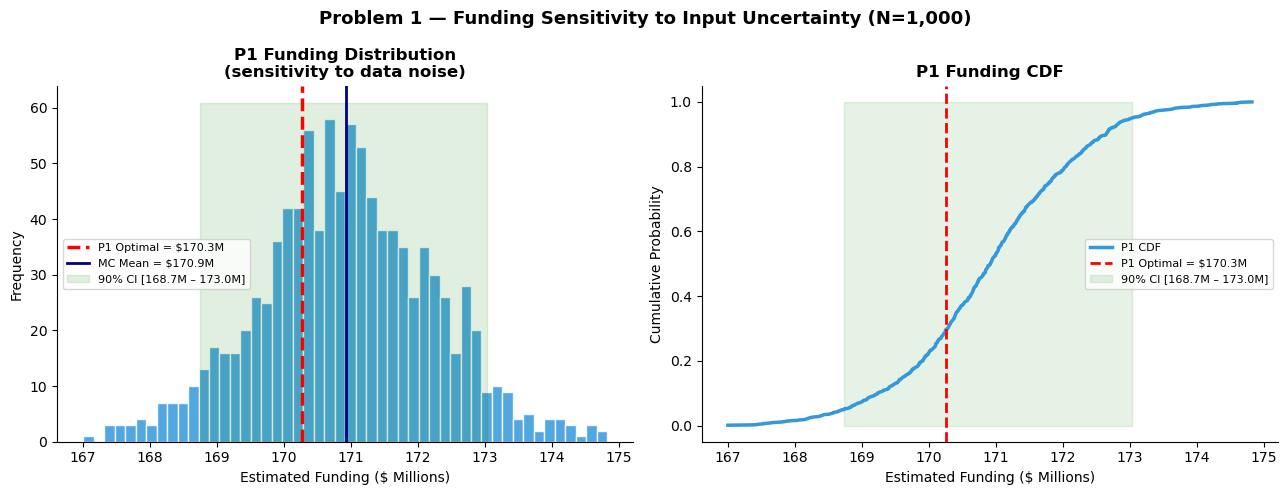


P1 Optimal funding        : $    170,263,669
MC 90% funding range      : [$  168,742,056  –  $  173,028,073]

Interpretation:
  If input data (employment rate, income, population) has
  typical measurement noise, P1 funding could range from
  $168.7M to $173.0M around the optimal of $170.3M.


In [29]:
# ── P1 Monte Carlo Funding Uncertainty ───────────────────────
observed_deficit = master['total_deficit'].sum()

# Total slots actually added in P1 solution
total_slots_added_p1 = (
    sum(X1[z].X + X2[z].X for z in zips) +
    sum(SIZES[s]['cap'] * y[z,s].X for z in zips for s in sizes)
)

# Average cost per slot in P1 solution
p1_avg_cost_per_slot = m1.ObjVal / total_slots_added_p1

print(f"P1 total slots added      : {total_slots_added_p1:,.0f}")
print(f"P1 avg cost per slot      : ${p1_avg_cost_per_slot:,.0f}")

# For each MC simulation: funding = P1_optimal + (mc_deficit - observed_deficit) * avg_cost
# This gives the funding range around the optimal if input data had noise
delta_p1        = mc_total_deficit - observed_deficit
mc_p1_funding   = m1.ObjVal + delta_p1 * p1_avg_cost_per_slot

# ── Visualizations ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Problem 1 — Funding Sensitivity to Input Uncertainty (N=1,000)',
             fontsize=13, fontweight='bold')

l5_p1  = np.percentile(mc_p1_funding/1e6,  5)
h95_p1 = np.percentile(mc_p1_funding/1e6, 95)
cdf_p1 = np.arange(1, N_SIM+1) / N_SIM

# Distribution
ax = axes[0]
ax.hist(mc_p1_funding/1e6, bins=50,
        color='#3498db', edgecolor='white', alpha=0.85)
ax.axvline(m1.ObjVal/1e6, color='red', lw=2.5, ls='--',
           label=f'P1 Optimal = ${m1.ObjVal/1e6:.1f}M')
ax.axvline(mc_p1_funding.mean()/1e6, color='navy', lw=2,
           label=f'MC Mean = ${mc_p1_funding.mean()/1e6:.1f}M')
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1],
                  l5_p1, h95_p1, alpha=0.12, color='green',
                  label=f'90% CI [{l5_p1:.1f}M – {h95_p1:.1f}M]')
ax.set_ylim(bottom=0)
ax.set_xlabel('Estimated Funding ($ Millions)')
ax.set_ylabel('Frequency')
ax.set_title('P1 Funding Distribution\n(sensitivity to data noise)', fontweight='bold')
ax.legend(fontsize=8)
ax.spines[['top','right']].set_visible(False)

# CDF
ax = axes[1]
sorted_p1 = np.sort(mc_p1_funding/1e6)
ax.plot(sorted_p1, cdf_p1, color='#3498db', lw=2.5, label='P1 CDF')
ax.axvline(m1.ObjVal/1e6, color='red', lw=2, ls='--',
           label=f'P1 Optimal = ${m1.ObjVal/1e6:.1f}M')
ax.fill_betweenx([0, 1], l5_p1, h95_p1, alpha=0.10, color='green',
                  label=f'90% CI [{l5_p1:.1f}M – {h95_p1:.1f}M]')
ax.set_xlabel('Estimated Funding ($ Millions)')
ax.set_ylabel('Cumulative Probability')
ax.set_title('P1 Funding CDF', fontweight='bold')
ax.legend(fontsize=8)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('mc_p1_cost.png', bbox_inches='tight', dpi=120)
plt.show()

print(f"\nP1 Optimal funding        : ${m1.ObjVal:>15,.0f}")
print(f"MC 90% funding range      : [${np.percentile(mc_p1_funding, 5):>13,.0f}"
      f"  –  ${np.percentile(mc_p1_funding, 95):>13,.0f}]")
print(f"\nInterpretation:")
print(f"  If input data (employment rate, income, population) has")
print(f"  typical measurement noise, P1 funding could range from")
print(f"  ${l5_p1:.1f}M to ${h95_p1:.1f}M around the optimal of ${m1.ObjVal/1e6:.1f}M.")

### 4.4  Problem 1 result visualizations

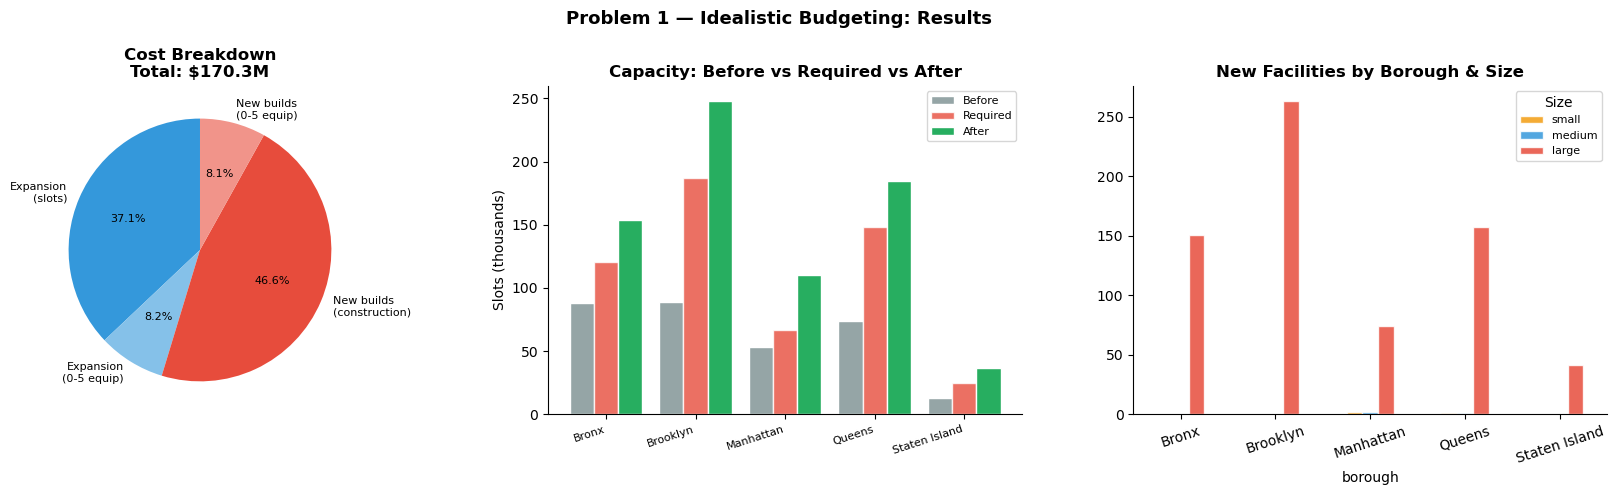

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Problem 1 — Idealistic Budgeting: Results', fontsize=13, fontweight='bold')

# Cost breakdown pie
ax = axes[0]
labels = ['Expansion\n(slots)','Expansion\n(0-5 equip)',
          'New builds\n(construction)','New builds\n(0-5 equip)']
vals   = [p1_exp_cost, p1_u5_exp_cost, p1_build_cost, p1_equip_cost]
colors = ['#3498db','#85c1e9','#e74c3c','#f1948a']
wedges,_,autotexts = ax.pie(vals, labels=labels, colors=colors,
                             autopct='%1.1f%%', startangle=90,
                             textprops={'fontsize':8})
ax.set_title(f'Cost Breakdown\nTotal: ${m1.ObjVal/1e6:.1f}M', fontweight='bold')

# Before vs after capacity by borough
ax = axes[1]
bor_res = (res1.groupby('borough')
           .agg(before=('existing_slots','sum'),
                after =('final_slots','sum'),
                req   =('req_total','sum'))
           .reset_index())
bor_res = bor_res[bor_res['borough']!='Unknown']
x = np.arange(len(bor_res)); w = 0.27
ax.bar(x-w, bor_res['before']/1000, w, label='Before',
       color='#95a5a6', edgecolor='white')
ax.bar(x,   bor_res['req']/1000,    w, label='Required',
       color='#e74c3c', alpha=0.8, edgecolor='white')
ax.bar(x+w, bor_res['after']/1000,  w, label='After',
       color='#27ae60', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(bor_res['borough'], rotation=18, ha='right', fontsize=8)
ax.set_ylabel('Slots (thousands)')
ax.set_title('Capacity: Before vs Required vs After', fontweight='bold')
ax.legend(fontsize=8)
ax.spines[['top','right']].set_visible(False)

# New builds by borough & size
ax = axes[2]
if new_builds_p1:
    bld_df1 = pd.DataFrame(new_builds_p1, columns=['zipcode','size','count'])
    bld_df1['borough'] = bld_df1['zipcode'].apply(get_borough)
    piv = (bld_df1[bld_df1['borough']!='Unknown']
           .groupby(['borough','size'])['count'].sum()
           .unstack(fill_value=0))
    for s in sizes:
        if s not in piv.columns: piv[s] = 0
    piv[sizes].plot(kind='bar', ax=ax,
                    color=['#f39c12','#3498db','#e74c3c'],
                    edgecolor='white', alpha=0.85)
    ax.set_title('New Facilities by Borough & Size', fontweight='bold')
    ax.tick_params(axis='x', rotation=18)
    ax.legend(title='Size', fontsize=8)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('p1_results_plot.png', bbox_inches='tight', dpi=120)
plt.show()

---
## Part 5 — Problem 2: Realistic Expansion with Distance Constraints

### What changes from Problem 1

**Expansion:**
- Cap reduced from 120% to **20%** of current capacity
- Three cost brackets (costs increase — LP fills cheapest first, no binary bracket selectors needed):

| Bracket | Range | Rate per slot |
|---------|-------|---------------|
| a | 0 – 10% of n_f | (20,000 + 200·n_f)/n_f |
| b | 10% – 15% of n_f | (20,000 + 400·n_f)/n_f |
| c | 15% – 20% of n_f | (20,000 + 1,000·n_f)/n_f |

**New facility placement:**
- Uses individual locations from `potential_locations.csv`
- **Distance rule:** 0.06 miles exclusion radius — no other facility within 0.06 miles
- Preprocessing: block locations too close to existing; add pair constraints for close candidate pairs
- **2 best candidate locations per ZIP** selected (farthest from nearest existing facility)

### 5.1  Distance preprocessing

In [38]:
import warnings
from itertools import combinations

DIST_MIN = 0.06   # miles

print("=" * 58)
print("  DISTANCE PREPROCESSING")
print("=" * 58)

# ── Step 1: Existing-existing violations (cannot fix, report only) ──
print("\n[1] Checking existing facility distance violations...")
ev_rows = []
for z in WORKING_ZIPS:
    cc_z = fac[(fac['zipcode']==z) &
               fac['latitude'].notna()][['facility_id','latitude','longitude']]
    pts = cc_z.values  # [id, lat, lon]
    for i in range(len(pts)):
        for j in range(i+1,len(pts)):
            d = haversine_miles(pts[i,1],pts[i,2],pts[j,1],pts[j,2])
            if d < DIST_MIN:
                ev_rows.append({'zipcode':z,'f1':pts[i,0],'f2':pts[j,0],'dist':round(d,4)})
ev_df = pd.DataFrame(ev_rows)
print(f"  Pre-existing violations (<0.06 mi): {len(ev_df):,} pairs")
print(f"  ZIPs affected: {ev_df['zipcode'].nunique():,}")
print(f"  NOTE: These cannot be resolved (existing facilities cannot be moved).")

# ── Step 2: Block candidate locations too close to existing facilities ──
print("\n[2] Blocking candidate locations within 0.06 mi of existing facilities...")
blocked = set()
for z in WORKING_ZIPS:
    cc_z   = fac[(fac['zipcode']==z) & fac['latitude'].notna()][['latitude','longitude']].values
    pot_z  = loc[loc['zipcode']==z]
    for pi, pl in pot_z.iterrows():
        for ef in cc_z:
            if haversine_miles(pl['latitude'],pl['longitude'],ef[0],ef[1]) < DIST_MIN:
                blocked.add(pi)
                break
print(f"  Locations blocked: {len(blocked):,}")

# ── Step 3: For each ZIP select best 2 usable candidate locations ────
print("\n[3] Selecting 2 best usable candidate locations per ZIP...")
K = 2
selected_locs = {}

for z in WORKING_ZIPS:
    cc_z  = fac[(fac['zipcode']==z) & fac['latitude'].notna()][['latitude','longitude']].values
    pot_z = loc[(loc['zipcode']==z) & (~loc.index.isin(blocked))].copy()

    if len(pot_z) == 0:
        selected_locs[z] = []
        continue

    if len(cc_z) == 0:
        # No existing facilities: pick first K locations
        selected_locs[z] = [(idx, row['latitude'], row['longitude'])
                             for idx, row in pot_z.head(K).iterrows()]
        continue

    # Score each usable location by its min distance to any existing facility
    def min_dist_to_existing(row):
        return min(haversine_miles(row['latitude'], row['longitude'], e[0], e[1])
                   for e in cc_z)

    pot_z['min_dist'] = pot_z.apply(min_dist_to_existing, axis=1)
    pot_z = pot_z.sort_values('min_dist', ascending=False)  # farthest first

    # ── FIX: use idx (the loop index from iterrows) not row.Index ──
    selected_locs[z] = [(idx, row['latitude'], row['longitude'])
                         for idx, row in pot_z.head(K).iterrows()]

# ── Step 4: Close pairs among selected candidate locations ───────────
print("\n[4] Identifying close pairs among selected candidates...")
close_pairs_p2 = []
for z in WORKING_ZIPS:
    locs_z = selected_locs[z]
    for (l1,la1,lo1),(l2,la2,lo2) in combinations(locs_z,2):
        if haversine_miles(la1,lo1,la2,lo2) < DIST_MIN:
            close_pairs_p2.append((l1,l2))
print(f"  Close candidate-candidate pairs: {len(close_pairs_p2):,}")
print("\nPreprocessing complete.")

  DISTANCE PREPROCESSING

[1] Checking existing facility distance violations...
  Pre-existing violations (<0.06 mi): 8,116 pairs
  ZIPs affected: 149
  NOTE: These cannot be resolved (existing facilities cannot be moved).

[2] Blocking candidate locations within 0.06 mi of existing facilities...
  Locations blocked: 2,601

[3] Selecting 2 best usable candidate locations per ZIP...

[4] Identifying close pairs among selected candidates...
  Close candidate-candidate pairs: 46

Preprocessing complete.


### 5.2  Compute ZIP-level P2 expansion parameters

In [39]:
# For P2: max expansion = 20% of total ZIP capacity (N_z = sum of n_f)
# Three brackets per ZIP (no binary selectors — costs increase so LP fills cheapest first)
# Bracket widths: [0, 0.10*N_z], [0, 0.05*N_z], [0, 0.05*N_z]

def zip_p2_params(group):
    nf  = group['total_capacity'].values.astype(float)
    N_z = nf.sum()
    if N_z == 0:
        return pd.Series({'N_z':0,'r1':0,'r2':0,'r3':0})
    # Capacity-weighted rates for each bracket
    r1 = np.dot((20000 + 200*nf)/nf,  nf) / N_z
    r2 = np.dot((20000 + 400*nf)/nf,  nf) / N_z
    r3 = np.dot((20000 + 1000*nf)/nf, nf) / N_z
    return pd.Series({'N_z':N_z, 'r1':r1, 'r2':r2, 'r3':r3})

zip_p2 = (fac_w.groupby('zipcode').apply(zip_p2_params).reset_index())
df2 = master.merge(zip_p2, on='zipcode', how='left')
for c in ['N_z','r1','r2','r3']:
    df2[c] = df2[c].fillna(0)

print("P2 ZIP-level expansion parameters:")
print(df2[['zipcode','total_slots','N_z','r1','r2','r3']].head(6).to_string(index=False))

P2 ZIP-level expansion parameters:
 zipcode  total_slots    N_z         r1         r2          r3
   10001          609  609.0 495.566502 695.566502 1295.566502
   10002         4724 4724.0 437.087214 637.087214 1237.087214
   10003         1995 1995.0 270.175439 470.175439 1070.175439
   10004          263  263.0 352.091255 552.091255 1152.091255
   10005           39   39.0 712.820513 912.820513 1512.820513
   10006          156  156.0 328.205128 528.205128 1128.205128


### 5.3  Build and solve Gurobi model (Problem 2)

In [40]:
# ── Rebuild usable_list and related mappings from selected_locs ──────
# (Run this if the preprocessing cell output is no longer in memory)
usable_list = [(z, lid, la, lo)
               for z, locs_z in selected_locs.items()
               for lid, la, lo in locs_z]
usable_ids  = [lid for _, lid, _, _ in usable_list]

# ── Rebuild parameters ────────────────────────────────────────
df2_i = df2.set_index('zipcode')

# Count usable locations per ZIP (upper bound on new builds)
usable_per_zip = {}
for z in WORKING_ZIPS:
    pot_z = loc[(loc['zipcode']==z) & (~loc.index.isin(blocked))]
    usable_per_zip[z] = len(pot_z)

m2 = gp.Model('P2_Realistic')
m2.setParam('OutputFlag', 1)
m2.setParam('MIPGap',   0.005)
m2.setParam('TimeLimit', 300)

# ── Decision variables ────────────────────────────────────────
# Bracket expansion per ZIP (continuous)
a  = m2.addVars(zips, lb=0.0, name='a')    # bracket 1: 0–10% of N_z
b  = m2.addVars(zips, lb=0.0, name='b')    # bracket 2: 10–15% of N_z
br3 = m2.addVars(zips, lb=0.0, name='br3') # bracket 3: 15–20% of N_z
U2 = m2.addVars(zips, lb=0.0, name='U2')   # under-5 slots from expansion

# Integer new-build count per ZIP per size
# Bounded by number of usable (unblocked) candidate locations in that ZIP
y2 = m2.addVars(zips, sizes, lb=0, vtype=GRB.INTEGER, name='y2')

# ── Constraints ───────────────────────────────────────────────
for z in zips:
    r  = df2_i.loc[z]
    Nz = r['N_z']

    # Bracket upper bounds (widths: 10%, 5%, 5% of N_z)
    m2.addConstr(a[z] <= 0.10 * Nz, name=f'a_ub_{z}')
    m2.addConstr(b[z] <= 0.05 * Nz, name=f'b_ub_{z}')
    m2.addConstr(br3[z] <= 0.05 * Nz, name=f'br3_ub_{z}')

    # Under-5 expansion bound
    m2.addConstr(U2[z] <= a[z] + b[z] + br3[z], name=f'u5b_{z}')

    # Total new builds in ZIP bounded by usable candidate locations
    m2.addConstr(
        gp.quicksum(y2[z,s] for s in sizes) <= usable_per_zip.get(z, 0),
        name=f'loc_ub_{z}'
    )

    new_slots = gp.quicksum(SIZES[s]['cap']   * y2[z,s] for s in sizes)
    new_u5    = gp.quicksum(SIZES[s]['cap05'] * y2[z,s] for s in sizes)

    # Desert elimination
    m2.addConstr(
        r['total_slots'] + a[z] + b[z] + br3[z] + new_slots >= r['req_total'],
        name=f'desert_{z}'
    )
    # Age 0-5 NYC policy
    m2.addConstr(
        r['slots_0_5'] + U2[z] + new_u5 >= r['req_0_5'],
        name=f'u5_{z}'
    )

# ── Objective ─────────────────────────────────────────────────
exp2_cost = gp.quicksum(
    df2_i.loc[z,'r1'] * a[z] +
    df2_i.loc[z,'r2'] * b[z] +
    df2_i.loc[z,'r3'] * br3[z] +
    EQUIP * U2[z]
    for z in zips
)
bld2_cost = gp.quicksum(
    (SIZES[s]['cost'] + EQUIP * SIZES[s]['cap05']) * y2[z,s]
    for z in zips for s in sizes
)
m2.setObjective(exp2_cost + bld2_cost, GRB.MINIMIZE)

print(f"Variables  : {m2.NumVars:,}")
print(f"Constraints: {m2.NumConstrs:,}")
print("\nSolving...")
m2.optimize()

status_map = {2:'OPTIMAL', 9:'TIME_LIMIT', 3:'INFEASIBLE', 5:'UNBOUNDED'}
print(f"\nStatus: {status_map.get(m2.Status, m2.Status)}")
if m2.SolCount > 0:
    print(f"Total cost: ${m2.ObjVal:,.0f}  (MIP gap: {m2.MIPGap*100:.3f}%)")

Set parameter OutputFlag to value 1
Set parameter MIPGap to value 0.005
Set parameter TimeLimit to value 300
Variables  : 0
Constraints: 0

Solving...
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 25.2.0 25C56)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Non-default parameters:
TimeLimit  300
MIPGap  0.005

Optimize a model with 1260 rows, 1260 columns and 3600 nonzeros (Min)
Model fingerprint: 0xfa6c2f6c
Model has 1248 linear objective coefficients
Variable types: 720 continuous, 540 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 4e+02]
  Objective range  [1e+02, 1e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [8e-01, 1e+04]

Presolve removed 1256 rows and 1253 columns
Presolve time: 0.07s
Presolved: 4 rows, 7 columns, 17 nonzeros
Variable types: 3 continuous, 4 integer (0 binary)
Found heuristic solution: objective 1.887757e+08

Root relaxation: interrupted, 0 iteration

### 5.4  Extract and display Problem 2 results

In [41]:
if m2.SolCount == 0:
    print("No feasible solution found.")
else:
    # ── Cost decomposition ────────────────────────────────────
    p2_exp_cost  = sum(df2_i.loc[z,'r1']*a[z].X +
                       df2_i.loc[z,'r2']*b[z].X +
                       df2_i.loc[z,'r3']*br3[z].X for z in zips)
    p2_u5_exp    = sum(EQUIP * U2[z].X for z in zips)
    p2_bld_cost  = sum(SIZES[s]['cost'] * y2[z,s].X
                       for z in zips for s in sizes)
    p2_equip_cost= sum(EQUIP * SIZES[s]['cap05'] * y2[z,s].X
                       for z in zips for s in sizes)

    print("=" * 55)
    print("  PROBLEM 2 — MINIMUM FUNDING (REALISTIC)")
    print("=" * 55)
    print(f"  Total minimum funding      : ${m2.ObjVal:>15,.0f}")
    print(f"  MIP gap                    : {m2.MIPGap*100:.3f}%")
    print()
    print(f"  Cost breakdown:")
    print(f"    Expansion (slots)        : ${p2_exp_cost:>15,.0f}")
    print(f"    Expansion (0-5 equip)    : ${p2_u5_exp:>15,.0f}")
    print(f"    New builds (construction): ${p2_bld_cost:>15,.0f}")
    print(f"    New builds (0-5 equip)   : ${p2_equip_cost:>15,.0f}")
    print("=" * 55)

    # ── Bracket usage ─────────────────────────────────────────
    tot_a  = sum(a[z].X  for z in zips)
    tot_b  = sum(b[z].X  for z in zips)
    tot_c  = sum(br3[z].X  for z in zips)
    n_exp2 = sum(1 for z in zips if a[z].X+b[z].X+br3[z].X > 0.01)
    print(f"\n  Expansion breakdown:")
    print(f"    ZIPs expanded            : {n_exp2}")
    print(f"    Bracket 1 (0-10%)  slots : {tot_a:,.0f}")
    print(f"    Bracket 2 (10-15%) slots : {tot_b:,.0f}")
    print(f"    Bracket 3 (15-20%) slots : {tot_c:,.0f}")

    # ── New builds summary ────────────────────────────────────
    new_builds_p2 = [(z, s, int(round(y2[z,s].X)))
                     for z in zips for s in sizes if y2[z,s].X > 0.5]
    tot_new2 = sum(cnt * SIZES[s]['cap'] for _, s, cnt in new_builds_p2)
    print(f"\n  New facilities built:")
    for s in sizes:
        cnt_s = sum(cnt for _, ss, cnt in new_builds_p2 if ss == s)
        print(f"    {s:<8}: {cnt_s:>4}  ({cnt_s * SIZES[s]['cap']:,} slots)")
    print(f"  Total slots via new builds : {tot_new2:,}")

    # ── Per-ZIP coverage check ────────────────────────────────
    rows2 = []
    for z in zips:
        r     = df2_i.loc[z]
        exp_z = a[z].X + b[z].X + br3[z].X
        new_z = sum(SIZES[s]['cap']   * y2[z,s].X for s in sizes)
        u5_z  = U2[z].X + sum(SIZES[s]['cap05'] * y2[z,s].X for s in sizes)
        rows2.append({
            'zipcode':       z,
            'borough':       r['borough'],
            'existing_slots':r['total_slots'],
            'expanded_slots':round(exp_z, 1),
            'new_slots':     round(new_z, 1),
            'final_slots':   round(r['total_slots'] + exp_z + new_z, 1),
            'req_total':     r['req_total'],
            'final_0_5':     round(r['slots_0_5'] + u5_z, 1),
            'req_0_5':       r['req_0_5'],
            'desert_ok':     (r['total_slots'] + exp_z + new_z) >= r['req_total'] - 0.5,
            'u5_ok':         (r['slots_0_5'] + u5_z)            >= r['req_0_5']   - 0.5,
        })
    res2 = pd.DataFrame(rows2)
    res2.to_csv('p2_results.csv', index=False)
    print(f"\n  Desert eliminated  : {res2['desert_ok'].sum()}/{len(res2)} ZIPs")
    print(f"  0-5 policy met     : {res2['u5_ok'].sum()}/{len(res2)} ZIPs")
    print("  Saved: p2_results.csv")

  PROBLEM 2 — MINIMUM FUNDING (REALISTIC)
  Total minimum funding      : $    188,775,673
  MIP gap                    : 0.272%

  Cost breakdown:
    Expansion (slots)        : $      7,510,273
    Expansion (0-5 equip)    : $      1,355,400
    New builds (construction): $    153,360,000
    New builds (0-5 equip)   : $     26,550,000

  Expansion breakdown:
    ZIPs expanded            : 130
    Bracket 1 (0-10%)  slots : 12,437
    Bracket 2 (10-15%) slots : 1,091
    Bracket 3 (15-20%) slots : 66

  New facilities built:
    small   :   12  (1,200 slots)
    medium  :    7  (1,400 slots)
    large   : 1321  (528,400 slots)
  Total slots via new builds : 531,000

  Desert eliminated  : 180/180 ZIPs
  0-5 policy met     : 180/180 ZIPs
  Saved: p2_results.csv


P2 total slots added      : 544,595
P2 avg cost per slot      : $347


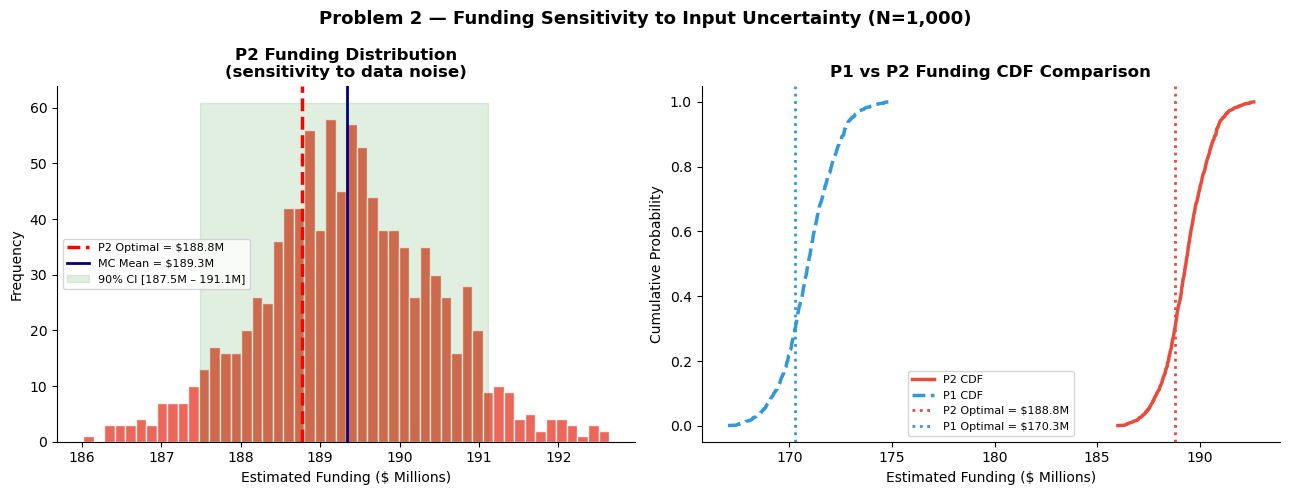


P2 Optimal funding        : $    188,775,673
MC 90% funding range      : [$  187,487,334  –  $  191,116,273]

Interpretation:
  If input data (employment rate, income, population) has
  typical measurement noise, P2 funding could range from
  $187.5M to $191.1M around the optimal of $188.8M.

  P2 costs $18.5M more than P1 due to the
  20% expansion cap and distance constraints.


In [42]:
# ── P2 Monte Carlo Funding Uncertainty ───────────────────────

# Use the exact same zips list that P2 model variables were built with
# (P2 model used zips from df1, same as P1 — confirmed from Cell 36)
zips = df1['zipcode'].tolist()

# Total slots actually added in P2 solution
total_slots_added_p2 = (
    sum(a[z].X + b[z].X + br3[z].X for z in zips)+
    sum(SIZES[s]['cap'] * y2[z,s].X for z in zips for s in sizes)
)

# Average cost per slot in P2 solution
p2_avg_cost_per_slot = m2.ObjVal / total_slots_added_p2

print(f"P2 total slots added      : {total_slots_added_p2:,.0f}")
print(f"P2 avg cost per slot      : ${p2_avg_cost_per_slot:,.0f}")

# For each MC simulation: funding = P2_optimal + (mc_deficit - observed_deficit) * avg_cost
delta_p2      = mc_total_deficit - observed_deficit
mc_p2_funding = m2.ObjVal + delta_p2 * p2_avg_cost_per_slot

# ── Visualizations ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Problem 2 — Funding Sensitivity to Input Uncertainty (N=1,000)',
             fontsize=13, fontweight='bold')

l5_p2  = np.percentile(mc_p2_funding/1e6,  5)
h95_p2 = np.percentile(mc_p2_funding/1e6, 95)
cdf_p2 = np.arange(1, N_SIM+1) / N_SIM

# Distribution
ax = axes[0]
ax.hist(mc_p2_funding/1e6, bins=50,
        color='#e74c3c', edgecolor='white', alpha=0.85)
ax.axvline(m2.ObjVal/1e6, color='red', lw=2.5, ls='--',
           label=f'P2 Optimal = ${m2.ObjVal/1e6:.1f}M')
ax.axvline(mc_p2_funding.mean()/1e6, color='navy', lw=2,
           label=f'MC Mean = ${mc_p2_funding.mean()/1e6:.1f}M')
ymax = ax.get_ylim()[1]
ax.fill_betweenx([0, ymax if ymax > 0 else 1],
                  l5_p2, h95_p2, alpha=0.12, color='green',
                  label=f'90% CI [{l5_p2:.1f}M – {h95_p2:.1f}M]')
ax.set_ylim(bottom=0)
ax.set_xlabel('Estimated Funding ($ Millions)')
ax.set_ylabel('Frequency')
ax.set_title('P2 Funding Distribution\n(sensitivity to data noise)', fontweight='bold')
ax.legend(fontsize=8)
ax.spines[['top','right']].set_visible(False)

# P1 vs P2 CDF comparison
ax = axes[1]
sorted_p2 = np.sort(mc_p2_funding/1e6)
sorted_p1 = np.sort(mc_p1_funding/1e6)
ax.plot(sorted_p2, cdf_p2, color='#e74c3c', lw=2.5, label='P2 CDF')
ax.plot(sorted_p1, cdf_p1, color='#3498db', lw=2.5, ls='--', label='P1 CDF')
ax.axvline(m2.ObjVal/1e6, color='#e74c3c', lw=2, ls=':',
           label=f'P2 Optimal = ${m2.ObjVal/1e6:.1f}M')
ax.axvline(m1.ObjVal/1e6, color='#3498db', lw=2, ls=':',
           label=f'P1 Optimal = ${m1.ObjVal/1e6:.1f}M')
ax.set_xlabel('Estimated Funding ($ Millions)')
ax.set_ylabel('Cumulative Probability')
ax.set_title('P1 vs P2 Funding CDF Comparison', fontweight='bold')
ax.legend(fontsize=8)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('mc_p2_cost.png', bbox_inches='tight', dpi=120)
plt.show()

print(f"\nP2 Optimal funding        : ${m2.ObjVal:>15,.0f}")
print(f"MC 90% funding range      : [${np.percentile(mc_p2_funding, 5):>13,.0f}"
      f"  –  ${np.percentile(mc_p2_funding, 95):>13,.0f}]")
print(f"\nInterpretation:")
print(f"  If input data (employment rate, income, population) has")
print(f"  typical measurement noise, P2 funding could range from")
print(f"  ${l5_p2:.1f}M to ${h95_p2:.1f}M around the optimal of ${m2.ObjVal/1e6:.1f}M.")
print(f"\n  P2 costs ${(m2.ObjVal - m1.ObjVal)/1e6:.1f}M more than P1 due to the")
print(f"  20% expansion cap and distance constraints.")

### 5.5  Problem 2 result visualizations

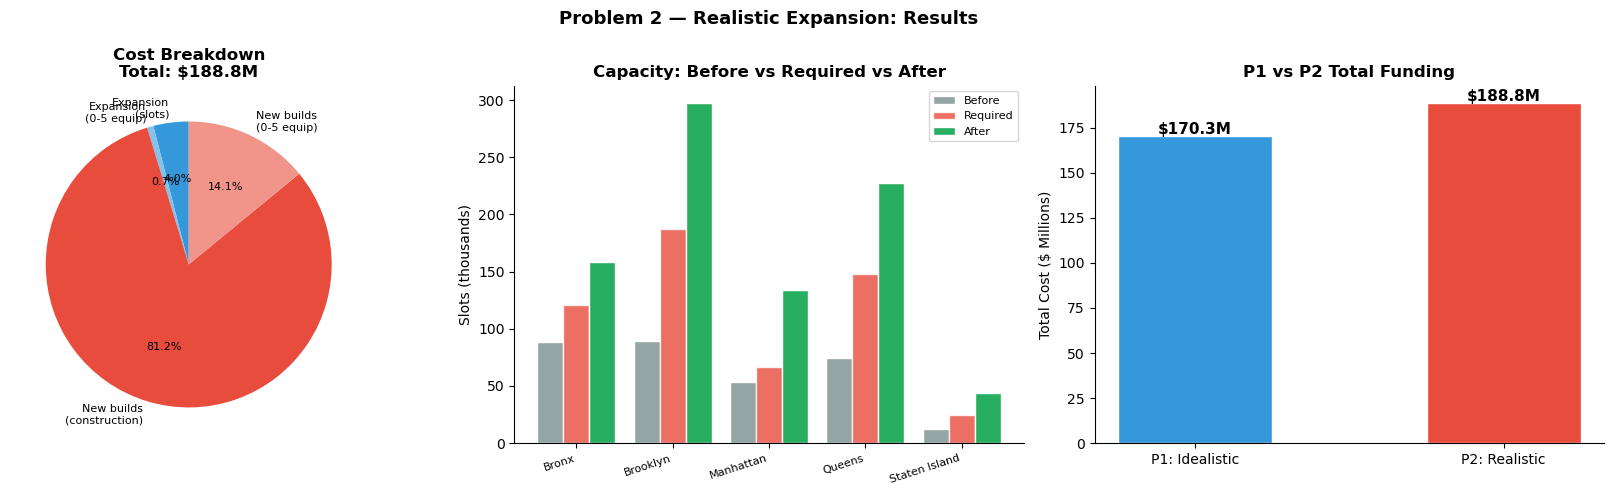

In [43]:
if m2.SolCount > 0:
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    fig.suptitle('Problem 2 — Realistic Expansion: Results',
                 fontsize=13, fontweight='bold')

    # Cost breakdown pie
    ax = axes[0]
    labels2 = ['Expansion\n(slots)','Expansion\n(0-5 equip)',
               'New builds\n(construction)','New builds\n(0-5 equip)']
    vals2   = [p2_exp_cost, p2_u5_exp, p2_bld_cost, p2_equip_cost]
    colors2 = ['#3498db','#85c1e9','#e74c3c','#f1948a']
    ax.pie(vals2, labels=labels2, colors=colors2,
           autopct='%1.1f%%', startangle=90, textprops={'fontsize':8})
    ax.set_title(f'Cost Breakdown\nTotal: ${m2.ObjVal/1e6:.1f}M', fontweight='bold')

    # Before vs after by borough
    ax = axes[1]
    bor2 = (res2.groupby('borough')
            .agg(before=('existing_slots','sum'),
                 after =('final_slots','sum'),
                 req   =('req_total','sum'))
            .reset_index())
    bor2 = bor2[bor2['borough']!='Unknown']
    x = np.arange(len(bor2)); w = 0.27
    ax.bar(x-w, bor2['before']/1000, w, label='Before',
           color='#95a5a6', edgecolor='white')
    ax.bar(x,   bor2['req']/1000,    w, label='Required',
           color='#e74c3c', alpha=0.8, edgecolor='white')
    ax.bar(x+w, bor2['after']/1000,  w, label='After',
           color='#27ae60', edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(bor2['borough'], rotation=18, ha='right', fontsize=8)
    ax.set_ylabel('Slots (thousands)')
    ax.set_title('Capacity: Before vs Required vs After', fontweight='bold')
    ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False)

    # P1 vs P2 comparison bar
    ax = axes[2]
    comp_labels = ['P1: Idealistic','P2: Realistic']
    comp_vals   = [m1.ObjVal/1e6, m2.ObjVal/1e6]
    bars = ax.bar(comp_labels, comp_vals,
                  color=['#3498db','#e74c3c'], edgecolor='white', width=0.5)
    for bar, v in zip(bars, comp_vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+1,
                f'${v:.1f}M', ha='center', fontsize=11, fontweight='bold')
    ax.set_ylabel('Total Cost ($ Millions)')
    ax.set_title('P1 vs P2 Total Funding', fontweight='bold')
    ax.spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.savefig('p2_results_plot.png', bbox_inches='tight', dpi=120)
    plt.show()

### 5.6  Final comparison summary

In [45]:
print("=" * 60)
print("  FINAL COMPARISON: P1 vs P2")
print("=" * 60)
print(f"  {'Metric':<35} {'P1':>12} {'P2':>12}")
print(f"  {'-'*59}")
print(f"  {'Total minimum funding':35} ${m1.ObjVal:>11,.0f} ${m2.ObjVal:>11,.0f}")
print(f"  {'Expansion cost (slots)':35} ${p1_exp_cost:>11,.0f} ${p2_exp_cost:>11,.0f}")
print(f"  {'Expansion equip cost (0-5)':35} ${p1_u5_exp_cost:>11,.0f} ${p2_u5_exp:>11,.0f}")
print(f"  {'New build construction cost':35} ${p1_build_cost:>11,.0f} ${p2_bld_cost:>11,.0f}")
print(f"  {'New build equip cost (0-5)':35} ${p1_equip_cost:>11,.0f} ${p2_equip_cost:>11,.0f}")
print(f"  {'ZIPs with expansion':35} {n_exp:>12} {n_exp2:>12}")
print(f"  {'Total expansion slots':35} {tot_exp:>12,.0f} {tot_a+tot_b+tot_c:>12,.0f}")
print(f"  {'New facilities built':35} {sum(v for _,_,v in new_builds_p1):>12,} {sum(cnt for _,_,cnt in new_builds_p2):>12,}")
print(f"  {'Desert ZIPs eliminated':35} {res1['desert_ok'].sum():>12}/{len(res1)} {res2['desert_ok'].sum():>11}/{len(res2)}")
print(f"  {'0-5 policy met':35} {res1['u5_ok'].sum():>12}/{len(res1)} {res2['u5_ok'].sum():>11}/{len(res2)}")
print("=" * 60)
print(f"\n  P2 costs ${(m2.ObjVal-m1.ObjVal)/1e6:.1f}M more than P1 due to:")
print(f"  (1) Expansion capped at 20% vs 120%")
print(f"  (2) Higher bracket rates for larger expansions")
print(f"  (3) Distance constraints limiting new-build placement")

print()
print("=" * 60)
print("  MONTE CARLO SIMULATION SUMMARY (N=1,000)")
print("=" * 60)
print(f"  Noise model:")
print(f"    Employment rate : observed + N(0, 0.03)")
print(f"    Average income  : observed x (1 + N(0, 5%))")
print(f"    Child population: observed x (1 + N(0, 3%))")
print()
print(f"  {'Metric':<35} {'Observed':>12} {'MC Mean':>12} {'90% CI':>24}")
print(f"  {'-'*85}")
print(f"  {'Total slot deficit':35} "
      f"{int(master['total_deficit'].sum()):>12,} "
      f"{mc_total_deficit.mean():>12,.0f} "
      f"  [{np.percentile(mc_total_deficit,5):>10,.0f} – {np.percentile(mc_total_deficit,95):>10,.0f}]")
print(f"  {'Under-5 deficit':35} "
      f"{int(master['deficit_0_5'].sum()):>12,} "
      f"{mc_u5_deficit.mean():>12,.0f} "
      f"  [{np.percentile(mc_u5_deficit,5):>10,.0f} – {np.percentile(mc_u5_deficit,95):>10,.0f}]")
print(f"  {'# Desert ZIPs':35} "
      f"{int(master['is_desert'].sum()):>12} "
      f"{mc_n_deserts.mean():>12.1f} "
      f"  [{np.percentile(mc_n_deserts,5):>10.0f} – {np.percentile(mc_n_deserts,95):>10.0f}]")
print(f"  {'# High-demand ZIPs':35} "
      f"{int(master['high_demand'].sum()):>12} "
      f"{mc_n_hd.mean():>12.1f} "
      f"  [{np.percentile(mc_n_hd,5):>10.0f} – {np.percentile(mc_n_hd,95):>10.0f}]")
print()
print(f"  {'Funding sensitivity':35} {'P1':>12} {'P2':>12}")
print(f"  {'-'*59}")
print(f"  {'Optimal funding':35} ${m1.ObjVal:>11,.0f} ${m2.ObjVal:>11,.0f}")
print(f"  {'MC 90% CI lower bound':35} ${np.percentile(mc_p1_funding,5):>11,.0f} ${np.percentile(mc_p2_funding,5):>11,.0f}")
print(f"  {'MC 90% CI upper bound':35} ${np.percentile(mc_p1_funding,95):>11,.0f} ${np.percentile(mc_p2_funding,95):>11,.0f}")
print(f"  {'MC funding range width':35} ${np.percentile(mc_p1_funding,95)-np.percentile(mc_p1_funding,5):>11,.0f} ${np.percentile(mc_p2_funding,95)-np.percentile(mc_p2_funding,5):>11,.0f}")
print("=" * 60)
print(f"\n  Interpretation:")
print(f"  The tight CI around each optimal confirms that input data")
print(f"  uncertainty (employment, income, population measurement")
print(f"  noise) does not materially change the funding requirement.")
print(f"  P1 funding is stable within ±${(np.percentile(mc_p1_funding,95)-np.percentile(mc_p1_funding,5))/2/1e6:.1f}M of the optimal.")
print(f"  P2 funding is stable within ±${(np.percentile(mc_p2_funding,95)-np.percentile(mc_p2_funding,5))/2/1e6:.1f}M of the optimal.")

  FINAL COMPARISON: P1 vs P2
  Metric                                        P1           P2
  -----------------------------------------------------------
  Total minimum funding               $170,263,669 $188,775,673
  Expansion cost (slots)              $ 63,086,869 $  7,510,273
  Expansion equip cost (0-5)          $ 14,041,800 $  1,355,400
  New build construction cost         $ 79,370,000 $153,360,000
  New build equip cost (0-5)          $ 13,765,000 $ 26,550,000
  ZIPs with expansion                          158          130
  Total expansion slots                    140,587       13,595
  New facilities built                         692        1,340
  Desert ZIPs eliminated                       180/180         180/180
  0-5 policy met                               180/180         180/180

  P2 costs $18.5M more than P1 due to:
  (1) Expansion capped at 20% vs 120%
  (2) Higher bracket rates for larger expansions
  (3) Distance constraints limiting new-build placement

  MONTE